In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import os

import albumentations as A
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from albumentations.pytorch import ToTensorV2
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import transforms

from custom_datasets import CBISDDSM_ResNet_Dataset
from util import (create_dataframes, pair_images, patient_grouped_split, get_model_file_path,
                  run_inference, evaluate_model)

In [3]:
df, full_mammograms_df, roi_masks_df, cropped_df = create_dataframes()

print(f"Total ROIs: {len(roi_masks_df)}")
print(roi_masks_df['image_path'].head(5))

Total ROIs: 1696
5     ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
10    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
12    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
18    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
19    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
Name: image_path, dtype: str


In [4]:
paired_df, merged_df = pair_images(roi_masks_df, full_mammograms_df)

Successfully paired 1696 mammogram/ROI pairs.
Removed 78 entries due to mismatched dimensions.
Consolidated into 1514 image entries.


In [5]:
cropped_df = cropped_df[cropped_df['PatientID'].isin(merged_df['PatientID_roi'])]

In [6]:
train_transform = A.Compose(
    [
        A.Resize(256, 256),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ]
)

test_transform = A.Compose(
    [
        A.Resize(256, 256),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ]
)

inv_transform = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)

In [7]:
dataset = CBISDDSM_ResNet_Dataset(dataframe=cropped_df)

transformed_dataset = CBISDDSM_ResNet_Dataset(dataframe=cropped_df, transform=test_transform)

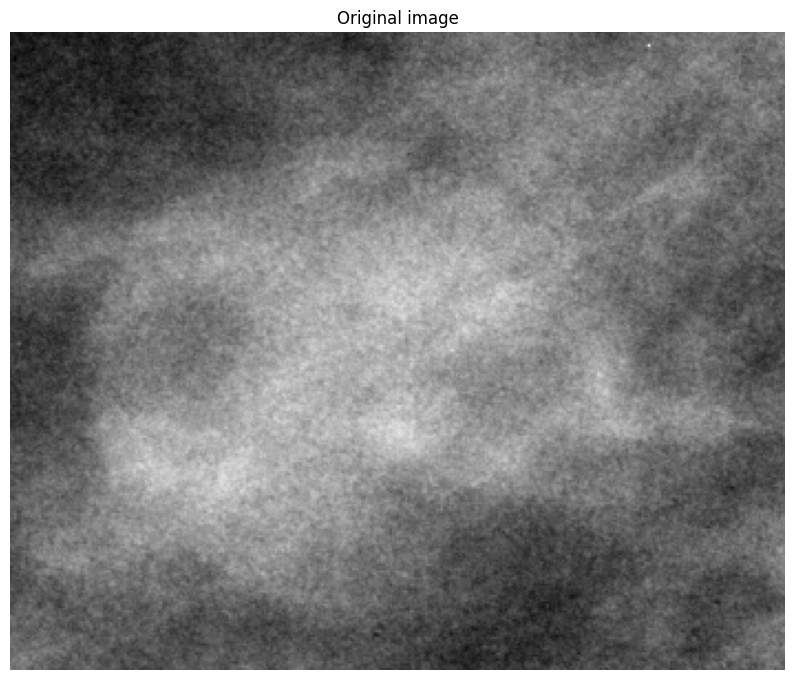

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.117124].


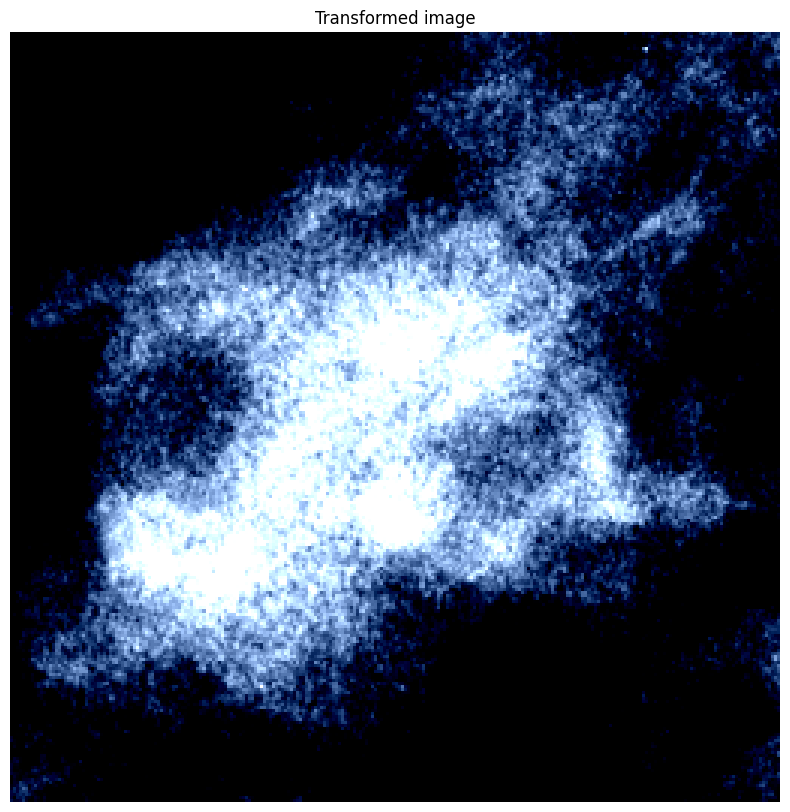

In [8]:
dataset.visualize_sample(0, "Original image")

transformed_dataset.visualize_sample(0, "Transformed image")

# Train test split

In [9]:
train_df, val_df, test_df = patient_grouped_split(cropped_df, val_size=0.15, test_size=0.15, random_state=42)

Train  1154 rows (71.3%),  613 patients, malignant fraction 0.475
Val     231 rows (14.3%),  119 patients, malignant fraction 0.472
Test    233 rows (14.4%),  121 patients, malignant fraction 0.476
No patient is shared between any of the 3 splits.


In [10]:
train_dataset = CBISDDSM_ResNet_Dataset(dataframe=train_df, transform=train_transform)

val_dataset = CBISDDSM_ResNet_Dataset(dataframe=val_df, transform=test_transform)

test_dataset = CBISDDSM_ResNet_Dataset(dataframe=test_df, transform=test_transform)

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=True,
)

# Initialize model and check for cuda

In [12]:
def get_model(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    for param in m.parameters():
        param.requires_grad = False

    num_features = m.fc.in_features
    m.fc = nn.Linear(num_features, num_classes)
    return m


num_classes = 2
model = get_model(num_classes)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
print(f"Using device: {device}")

Using device: cuda


In [13]:
checkpoint_dir = '../models/Resnet/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

completed_dir = '../models/Resnet/completed'
os.makedirs(completed_dir, exist_ok=True)

# Check for trained models

In [30]:
completed_path = None

if len(os.listdir(completed_dir)) > 0:
    completed_path = get_model_file_path("Completed model directory is not empty. Do you want to use saved model? (y/n): ",
                                         "../models/Resnet/completed")

    if completed_path:
        print(f"Using saved model from {completed_path}")
    else:
        print("No model file selected. Starting training from scratch.")

Using saved model from C:/Users/nerfb/Downloads/Programs/EUEProjects/FP/Project/models/Resnet/completed/0.78-0.74_recalls.pth


# Model training

In [31]:
params = [p for p in model.parameters() if p.requires_grad]

class_weights = torch.tensor([1.0, 1.5]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(params, lr=0.0001)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

num_epochs = 70
start_epoch = 0

loss_history = []
val_loss_history = []
val_auc_history = []
best_epoch = 0
best_val_loss = np.inf
best_auc_epoch = 0
best_val_auc = 0.0
best_model_weights = copy.deepcopy(model.state_dict())
early_stopping_patience = 10
epochs_no_improve = 0
early_stop = False
early_model = get_model(num_classes)

if completed_path:
    if os.path.exists(completed_path):
        print(f"Loading model from {completed_path}")
        saved = torch.load(completed_path, map_location=device)
        model.load_state_dict(saved)
        model.eval()
        print("Model loaded successfully.")
else:
    scaler = GradScaler()
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0

        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', enabled=True):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item() * images.size(0)

            if i % 10 == 0:
                print(f"Epoch [{epoch + 1}/{num_epochs}], Batch [{i + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")

        val_labels, val_probs, val_loss = run_inference(model, val_loader, criterion, device)
        val_auc = roc_auc_score(val_labels, val_probs)
        scheduler.step(val_loss)

        print(f"--- Epoch {epoch + 1} Completed | Train Loss: {epoch_loss / len(train_loader.dataset):.4f} "
              f"| Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} ---")
        loss_history.append(epoch_loss / len(train_loader.dataset))
        val_loss_history.append(val_loss)
        val_auc_history.append(val_auc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_auc_epoch = epoch

        if epoch % 5 == 0:
            checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_{epoch + 1}.pth')
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': epoch_loss
            }
            torch.save(checkpoint, checkpoint_path)
            print(f"Checkpoint saved to {checkpoint_path}")

        if epochs_no_improve >= early_stopping_patience and not early_stop:
            print(f"Early stopping triggered after {epoch + 1} epochs")
            early_stop = True
            early_model.load_state_dict(best_model_weights)
            # TODO Break

    print(f"\nBest val loss {best_val_loss:.4f} at epoch {best_epoch + 1}.")
    print(f"Best val AUC  {best_val_auc:.4f} at epoch {best_auc_epoch + 1}.")

    # model.load_state_dict(best_model_weights)

Loading model from C:/Users/nerfb/Downloads/Programs/EUEProjects/FP/Project/models/Resnet/completed/0.78-0.74_recalls.pth
Model loaded successfully.


In [24]:
if len(val_loss_history) > 0 and len(loss_history) > 0:
    fig, (loss_ax, auc_ax) = plt.subplots(1, 2, figsize=(13, 5))

    loss_ax.plot(loss_history, label='Train Loss')
    loss_ax.plot(val_loss_history, label='Val Loss')
    loss_ax.axvline(best_epoch, color='gray', linestyle='--', lw=1, label=f'Best loss (epoch {best_epoch + 1})')
    loss_ax.set_xlabel('Epoch')
    loss_ax.set_ylabel('Loss')
    loss_ax.set_title('Training and Validation Loss')
    loss_ax.legend()
    loss_ax.grid(alpha=0.3)

    auc_ax.plot(val_auc_history, color='tab:green', label='Val AUC')
    auc_ax.axhline(0.5, color='k', linestyle='--', lw=1, label='Chance (0.5)')
    auc_ax.axvline(best_auc_epoch, color='gray', linestyle='--', lw=1, label=f'Best AUC (epoch {best_auc_epoch + 1})')
    auc_ax.set_xlabel('Epoch')
    auc_ax.set_ylabel('ROC-AUC')
    auc_ax.set_title('Validation ROC-AUC')
    auc_ax.legend()
    auc_ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No training history to plot.")

No training history to plot.


In [25]:
if not completed_path:
    save_path = os.path.join(completed_dir, 'completed.pth')
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

# Testing and Visualization

## Visualization

In [18]:
def test_and_visualize(model, loader, device, num_samples=3):
    model.eval()

    images, labels = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    images = images.cpu()
    labels = labels.cpu()
    preds = preds.cpu()

    class_names = ['benign', 'malignant']

    num_to_plot = min(num_samples, images.size(0))
    fig, axes = plt.subplots(1, num_to_plot, figsize=(15, 4))

    if num_to_plot == 1:
        axes = [axes]

    for i in range(num_to_plot):
        ax = axes[i]
        img = inv_transform(images[i])

        img = img.permute(1, 2, 0).numpy()

        img = np.clip(img, 0, 1)

        ax.imshow(img)

        true_label = class_names[labels[i].item()]
        pred_label = class_names[preds[i].item()]

        color = 'green' if preds[i] == labels[i] else 'red'
        ax.set_title(f"True: {true_label}, Pred: {pred_label}", color=color)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

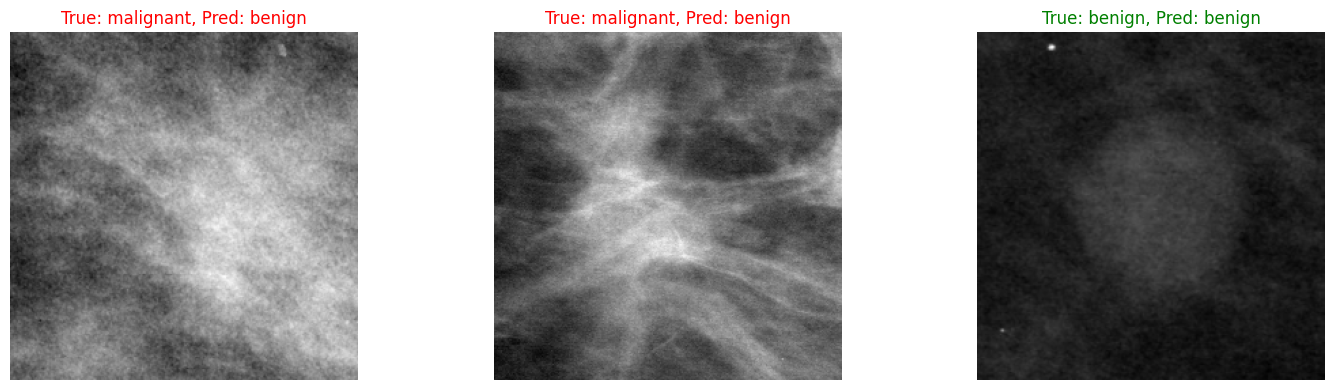

In [19]:
test_and_visualize(model, test_loader, device)

## Evaluation

Validation Loss: 0.6191
Validation Accuracy: 0.7056
Validation ROC-AUC: 0.7686

Classification Report:
              precision    recall  f1-score   support

      benign       0.70      0.77      0.73       122
   malignant       0.71      0.63      0.67       109

    accuracy                           0.71       231
   macro avg       0.71      0.70      0.70       231
weighted avg       0.71      0.71      0.70       231

False negatives (malignant predicted benign): 40 of 109 -> sensitivity 0.633


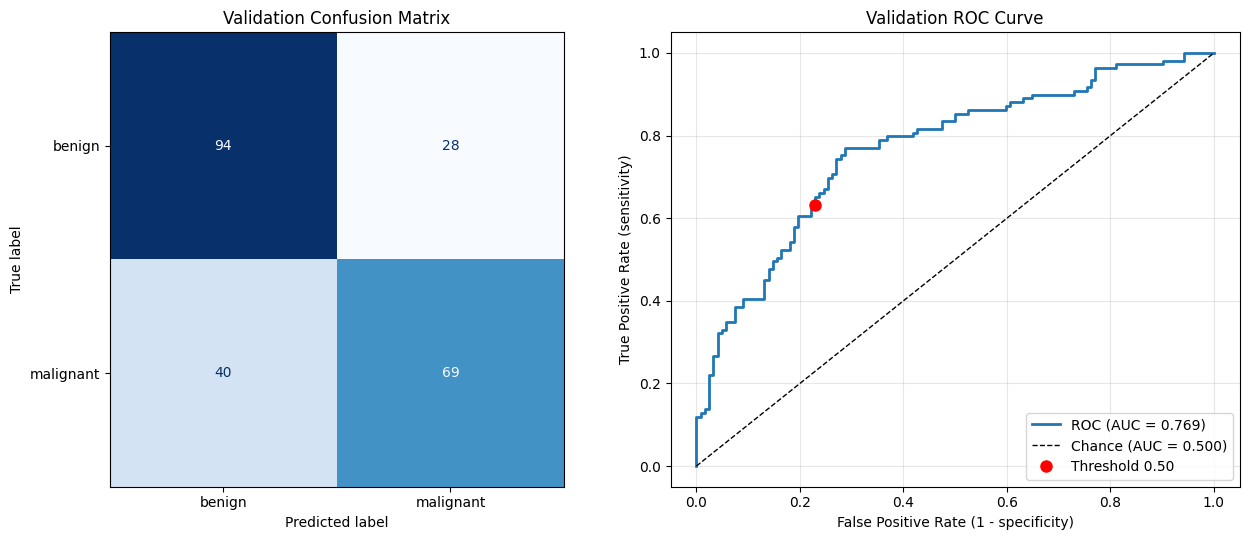

Test Loss: 0.5302
Test Accuracy: 0.7597
Test ROC-AUC: 0.8285

Classification Report:
              precision    recall  f1-score   support

      benign       0.79      0.74      0.76       122
   malignant       0.73      0.78      0.76       111

    accuracy                           0.76       233
   macro avg       0.76      0.76      0.76       233
weighted avg       0.76      0.76      0.76       233

False negatives (malignant predicted benign): 24 of 111 -> sensitivity 0.784


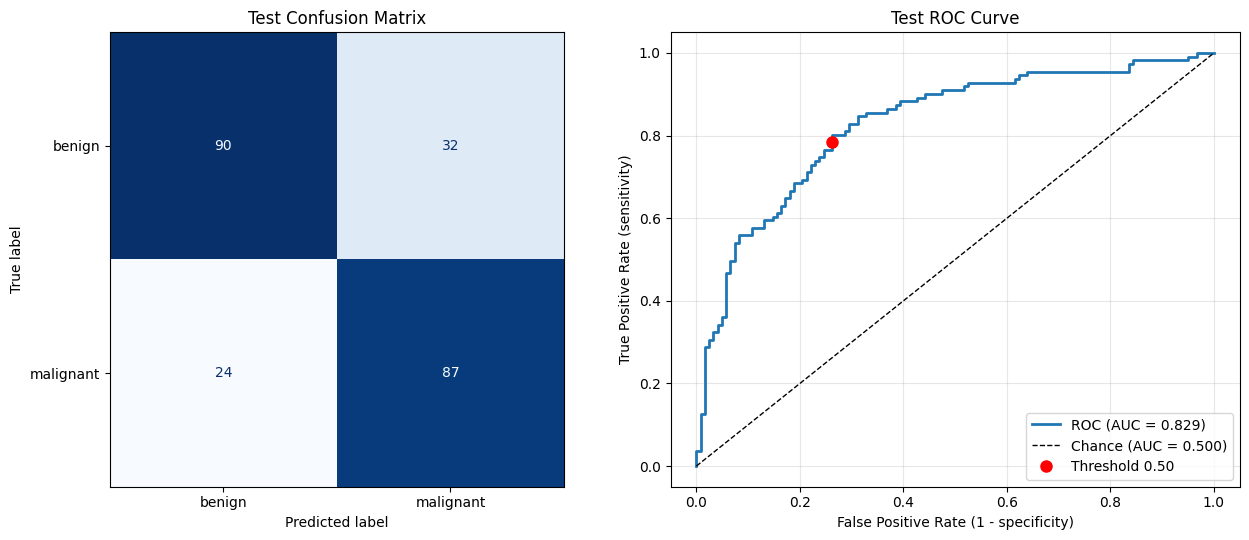

{'split': 'Test',
 'loss': 0.5302450472704843,
 'accuracy': np.float64(0.759656652360515),
 'auc': 0.828533451484271,
 'sensitivity': np.float64(0.7837837837837838),
 'false_negatives': 24,
 'threshold': 0.5}

In [32]:
evaluate_model(model, val_loader, criterion, device, split_name='Validation')

evaluate_model(model, test_loader, criterion, device, split_name='Test')

Test Loss: 0.6826
Test Accuracy: 0.5107
Test ROC-AUC: 0.5711

Classification Report:
              precision    recall  f1-score   support

      benign       0.58      0.25      0.34       122
   malignant       0.49      0.80      0.61       111

    accuracy                           0.51       233
   macro avg       0.53      0.52      0.48       233
weighted avg       0.54      0.51      0.47       233

False negatives (malignant predicted benign): 22 of 111 -> sensitivity 0.802


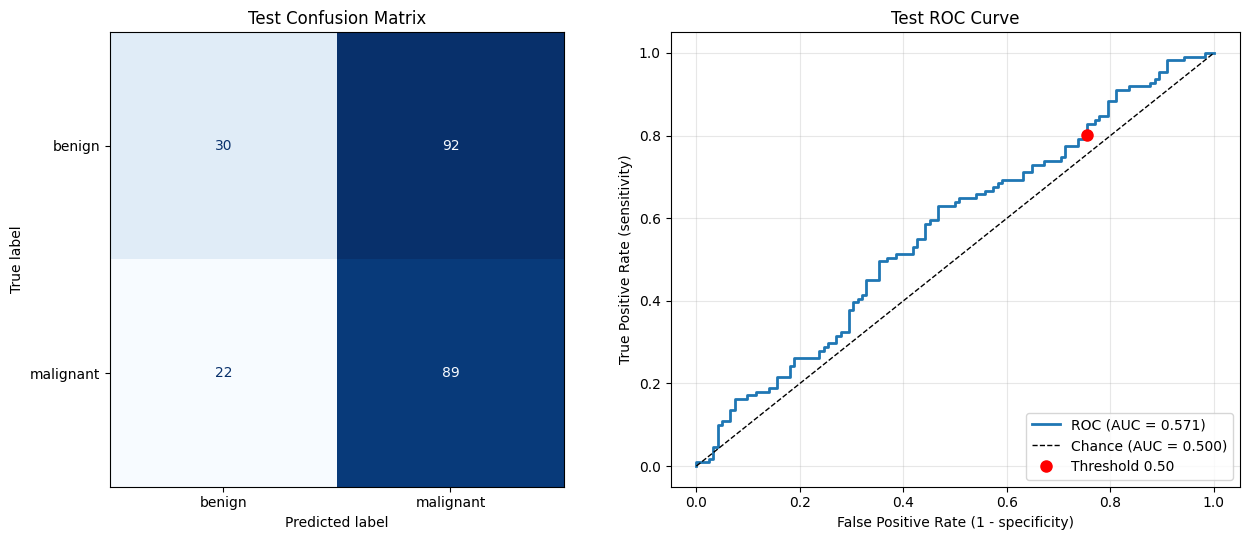

In [21]:
if early_model:
    evaluate_model(early_model, test_loader, criterion, device, split_name="Test")